In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import make_scorer, average_precision_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import classification_report, roc_curve, auc, ConfusionMatrixDisplay

In [5]:
df = pd.read_csv('onlinefraud_cleaned.csv')
df.head(10)

,step,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,hour_of_day,is_Merchant_Dest,errorBalanceOrig,errorBalanceDest,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.0,0.00,0,1,1,0.00,0.00,0,0,1,0
1,1,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.0,0.00,0,1,1,0.00,0.00,0,0,1,0
2,1,181.00,C1305486145,181.00,0.00,C553264065,0.0,0.00,1,1,0,0.00,181.00,0,0,0,1
3,1,181.00,C840083671,181.00,0.00,C38997010,21182.0,0.00,1,1,0,0.00,21363.00,1,0,0,0
4,1,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.0,0.00,0,1,1,0.00,0.00,0,0,1,0
5,1,7817.71,C90045638,53860.00,46042.29,M573487274,0.0,0.00,0,1,1,0.00,0.00,0,0,1,0
6,1,7107.77,C154988899,183195.00,176087.23,M408069119,0.0,0.00,0,1,1,0.00,0.00,0,0,1,0
7,1,7861.64,C1912850431,176087.23,168225.59,M633326333,0.0,0.00,0,1,1,0.00,0.00,0,0,1,0
8,1,4024.36,C1265012928,2671.00,0.00,M1176932104,0.0,0.00,0,1,1,1353.36,0.00,0,0,1,0
9,1,5337.77,C712410124,41720.00,36382.23,C195600860,41898.0,40348.79,0,1,0,0.00,6886.98,0,1,0,0


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
X = df.drop(['step','nameOrig', 'nameDest'], axis= 1)
y = X.pop('isFraud')

# train+val and test
x_temp, x_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    stratify=y,
    random_state=42
)

# train and validation
x_train, x_val, y_train, y_val = train_test_split(
    x_temp,
    y_temp,
    test_size=0.1765,  # ~15% total
    stratify=y_temp,
    random_state=42
)

In [9]:
# Keep only 1 million rows
# Sample for model comparison
X_sample, _, y_sample, _ = train_test_split(
    x_train,
    y_train,
    train_size=1_000_000,
    stratify=y_train,
    random_state=42
)

X_sample.shape, y_sample.shape

((1000000, 13), (1000000,))

In [10]:
x_train.shape, x_val.shape, x_test.shape

((4453674, 13), (954553, 13), (954393, 13))

In [ ]:
def model_comparison_evaluate(classifiers, X, y, n_splits=5):
    """
    Compare multiple classification models using Stratified K-Fold Cross Validation.

    Parameters
    ----------
    classifiers : dict
        Dictionary containing model names and model objects.

        Example:
        {
            'Logistic Regression': LogisticRegression(),
            'Random Forest': RandomForestClassifier()
        }

    X : pandas.DataFrame, pandas.Series, numpy.ndarray
        Feature matrix (input variables).

        Accepted formats:
        - pandas DataFrame
        - pandas Series
        - NumPy array

        Shape:
        (n_samples, n_features)

    y : pandas.Series, numpy.ndarray, list
        Target labels.

        Accepted formats:
        - pandas Series
        - NumPy array
        - Python list

        Shape:
        (n_samples,)

    n_splits : int, default=5
        Number of folds for cross-validation.

    Returns
    -------
    None
        Prints evaluation results for each model.
    """

    # Stratified K-Fold keeps class distribution balanced
    skfold = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=42
    )

    # PR-AUC scorer
    pr_auc_scorer = make_scorer(
        average_precision_score,
        response_method='predict_proba'
    )

    scoring_metrics = {
        'precision': 'precision',
        'recall': 'recall',
        'f1': 'f1',
        'roc_auc': 'roc_auc',
        'pr_auc': pr_auc_scorer
    }

    print('K-Fold Cross-Validation Evaluation\n')

    for name, model in classifiers.items():

        print('=' * 50)
        print(f'Model: {name}')
        print('=' * 50)

        for metric_name, scoring_method in scoring_metrics.items():

            scores = cross_val_score(
                estimator=model,
                X=X,
                y=y,
                scoring=scoring_method,
                cv=skfold,
                n_jobs= -1
            )

            print(
                f'{metric_name:<10}: '
                f'Mean = {scores.mean():.4f} | '
                f'Std = {scores.std():.4f}'
            )

        print('\n')

In [ ]:
classifiers = {

    'Logistic Regression': LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ),

    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),

    'Extra Trees': ExtraTreesClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),

    'HistGradientBoosting': HistGradientBoostingClassifier(
        learning_rate=0.1,
        max_iter=200,
        max_depth=10,
        min_samples_leaf=20,
        l2_regularization=1.0,
        random_state=42
    ),

    'XGBoost': XGBClassifier(
        n_estimators=200,
        max_depth=10,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=10,
        eval_metric='logloss',
        random_state=42,
        tree_method='hist',
    ),

    'LightGBM': LGBMClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=10,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        class_weight='balanced',
        objective='binary',
        random_state=42,
    ),

    'CatBoost': CatBoostClassifier(
        iterations=200,
        learning_rate=0.1,
        depth=10,
        loss_function='Logloss',
        eval_metric='AUC',
        auto_class_weights='Balanced',
        random_seed=42,
        verbose=0,
    )
}

In [11]:
rf_model = RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )

hgb_model = HistGradientBoostingClassifier(
        learning_rate=0.1,
        max_iter=200,
        max_depth=10,
        min_samples_leaf=20,
        l2_regularization=1.0,
        random_state=42
    )

lgbm_model = LGBMClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=10,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        class_weight='balanced',
        objective='binary',
        random_state=42,
    )

# rf_model.fit(x_train, y_train)
# hgb_model.fit(x_train, y_train)
lgbm_model.fit(
    x_train,
    y_train,
    eval_set=[(x_val, y_val)],
    eval_metric='auc'
)

[LightGBM] [Info] Number of positive: 5749, number of negative: 4447925
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.041790 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1819
[LightGBM] [Info] Number of data points in the train set: 4453674, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,10
,learning_rate,0.1
,n_estimators,200
,subsample_for_bin,200000
,objective,'binary'
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [12]:
lgbm_y_pred = lgbm_model.predict(x_test)
lgbm_y_pred_score = lgbm_model.predict_proba(x_test)[:,1]

print("===========================================================")
print("LightGBM:")
print(classification_report(y_test, lgbm_y_pred, labels= [0,1], target_names= ['Non-Fraud', 'Fraud']))
print("===========================================================")

LightGBM:
              precision    recall  f1-score   support

   Non-Fraud       1.00      1.00      1.00    953161
       Fraud       1.00      1.00      1.00      1232

    accuracy                           1.00    954393
   macro avg       1.00      1.00      1.00    954393
weighted avg       1.00      1.00      1.00    954393



Text(0.5, 0, 'False Positive Rate')

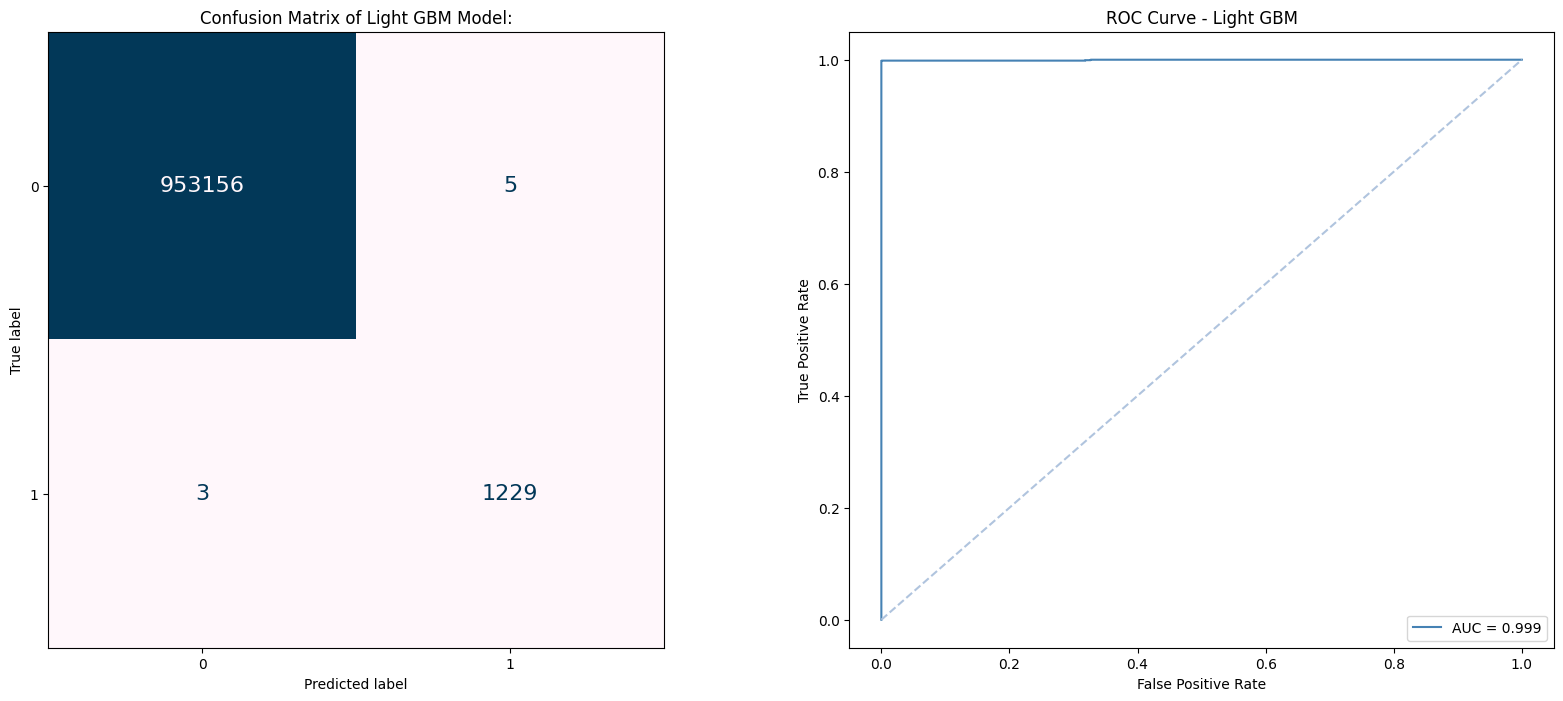

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(20,8))
ax[0].set_title('Confusion Matrix of Light GBM Model:')
ConfusionMatrixDisplay.from_predictions(y_test, lgbm_y_pred, colorbar=False, values_format='', cmap='PuBu', ax=ax[0],text_kw={'fontsize': 16})
ax[0].grid(False)


fpr, tpr, thresholds = roc_curve(y_test, lgbm_y_pred_score)
roc_auc = auc(fpr, tpr)                       
ax[1].set_title('ROC Curve - Light GBM')
ax[1].plot(fpr, tpr, label = 'AUC = %0.3f' % roc_auc, c='steelblue')
ax[1].plot([0,1],[0,1],'--', c='lightsteelblue')
ax[1].legend(loc='lower right')
ax[1].set_ylabel('True Positive Rate')
ax[1].set_xlabel('False Positive Rate')

In [ ]:
# FEATURES IMPORTANCE
importance = pd.DataFrame({
    'feature': X.columns,
    'importance': lgbm_model.feature_importances_
})

print(
    importance.sort_values(
        by='importance',
        ascending=False
    )
)

             feature  importance
4     newbalanceDest         951
7   errorBalanceOrig         870
5        hour_of_day         837
0             amount         829
3     oldbalanceDest         787
8   errorBalanceDest         594
1      oldbalanceOrg         494
2     newbalanceOrig         314
12     type_TRANSFER         139
9      type_CASH_OUT         107
6   is_Merchant_Dest          53
11      type_PAYMENT          19
10        type_DEBIT           6
